In [3]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def CargaDatos():
    #x: vector de diseño (ingresos)
    #y: vector de objetivos (target) (consumo)

    df = pd.read_excel('DatosRegresion1D.xlsx')
    x = df['ingresos']
    y = df['consumo']
    return x,y

def DibujaDatos(x,y,n):
    #x: vector de diseño (ingresos)
    #y: vector de objetivos (target) (consumo)
    #n: nº de puntos a dibujar

    plt.figure()
    plt.plot(x[:n],y[:n],'x')
    plt.xlabel('Ingresos anuales (miles de €)')
    plt.ylabel('Consumo anual de electricidad (Mw-h)')


def DibujaRecta(w,b):
    #w: pendiente de la recta de regresión
    #b: intersección de la recta de regresión

    xmin,xmax = plt.xlim()
    ymin = w*xmin + b
    ymax = w*xmax + b
    plt.plot([xmin,xmax],[ymin,ymax])


def DibujaFuncionCoste(x,y,n):
    #x: vector de diseño (ingresos)
    #y: vector de objetivos (target) (consumo)
    #n: nº de puntos a dibujar

    xtrain = x[:n]
    ytrain = y[:n]
    nw = 100 #Número de valores del parámetro w a considerar
    w_vector = np.linspace(0,0.3,nw) #Valores del parámetro w (pendiente)
    b = 0 #Valor de la intersección de la recta de regresión
    J = np.zeros(nw) #Reserva de espacio para el vector de costes
    for k in range(nw):
        w = w_vector[k]
        htrain = w*xtrain + b #hipótesis
        etrain = htrain-ytrain #error (h-y)
        J[k] = np.sum(etrain**2) / n #Coste para un determinado valor de w

    kmin = np.argmin(J) #Índice en el vector del valor mínimo de coste
    wmin = w_vector[kmin] #w que produce el mínimo coste
    print(wmin)
    Jmin = J[kmin] #Valor mínimo del coste
    print(kmin)

    plt.figure()
    plt.plot(w_vector,J)
    plt.plot(wmin,Jmin, 'ro')
    plt.xlabel('Parámetro: w')
    plt.ylabel('Función de coste: J(w)')

def CalculaPendiente(x,y,n):
    #x: vector de diseño (ingresos)
    #y: vector de objetivos (target) (consumo)
    #n: nº de puntos a considerar en el cálculo de la pendiente
    #w: pendiente de la recta de regresión

    xtrain = x[:n]
    ytrain = y[:n]
    w = np.sum(xtrain*ytrain) / np.sum(xtrain**2)
    return w


def DibujaCurvaAprendizaje(x,y):
    #x: vector de diseño (ingresos)
    #y: vector de objetivos (target) (consumo)

    npuntos = 50 #Nº de puntos de la curva de aprendizaje
    ntrain_vector = np.linspace(10,200,npuntos) #Nº clientes training (vector)
    Jtrain = np.zeros(npuntos) #Reserva de espacio para el coste de training
    Jtest = np.zeros(npuntos) #Reserva de espacio para el coste de testing

    for k in range(npuntos): #Itera para distintos valores de ntrain
        #Cálculo del coste para el Training Dataset
        ntrain = ntrain_vector[k]
        ntrain = ntrain.astype('int') #Lo convierte en un número entero
        xtrain = x[:ntrain] #Vector de diseño (training)
        ytrain = y[:ntrain] #Vector de objetivos (training)
        w = CalculaPendiente(xtrain,ytrain,ntrain) #Pendiente óptima
        b = 0 #Valor de la intersección de la recta de regresión
        htrain = w*xtrain + b #hipótesis (training)
        etrain = htrain-ytrain #error (h-y) (training)
        Jtrain[k] = np.sum(etrain**2) / ntrain #Coste (training)

        #Cálculo del coste para el Test Dataset
        xtest = x[ntrain:] #Vector de diseño (test)
        ytest = y[ntrain:] #Vector de objetivos (test)
        ntest = len(ytest) #Número de elementos en el vector de test
        htest = w*xtest + b #hipótesis (test)
        etest = htest-ytest #error (h-y) (test)
        Jtest[k] = np.sum(etest**2) / ntest #Coste (test)

    #Dibujo de la curva de aprendizaje
    plt.figure()
    plt.plot(ntrain_vector,Jtrain, label='Entrenamiento')
    plt.plot(ntrain_vector,Jtest, label='Prueba')
    plt.xlabel('Número de clientes para entrenamiento')
    plt.ylabel('Función de coste: J(w)')
    plt.legend()

In [5]:
x,y = CargaDatos() #Apartado a

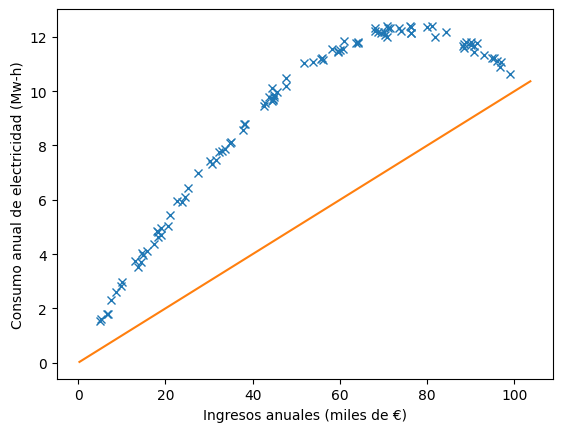

In [6]:
DibujaDatos(x,y,100) #Apartado b
DibujaRecta(0.1,0) #Apartado b

0.1606060606060606
53


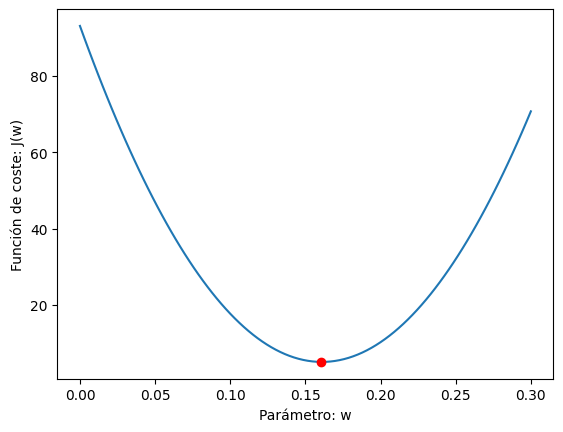

In [7]:
DibujaFuncionCoste(x,y,100) #Apartado c

0.16097891362016353


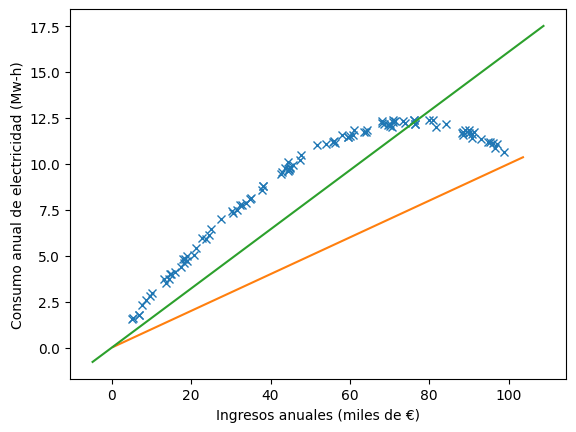

In [8]:
w = CalculaPendiente(x,y,100) #Apartado d
print(w) #Apartado d
DibujaDatos(x,y,100) #Apartado d
DibujaRecta(0.1,0) #Apartado d
DibujaRecta(w,0) #Apartado d

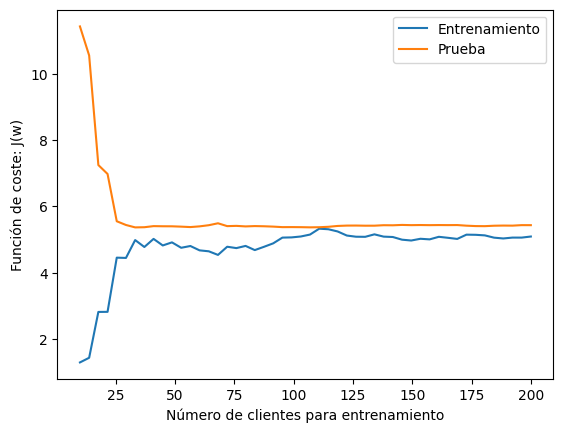

In [9]:
DibujaCurvaAprendizaje(x,y)  #Apartado e
plt.show()